In [39]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.pyplot as plt
import glob
import os

In [37]:
DIR1 = "/home/holdennix/Research/G165/MMT/pypeit/RDXDIR_faint/mmt_binospec_A/Coadded"
DIR2 = "/home/holdennix/Research/G165/MMT/pypeit/RDXDIR_short/mmt_binospec_A/Coadded"
PATTERN = "*.fits"

# Gather file lists from both directories
files1 = sorted(glob.glob(os.path.join(DIR1, PATTERN)))
files2 = sorted(glob.glob(os.path.join(DIR2, PATTERN)))

all_files = files1 + files2

print(f"Found {len(files1)} files in RDXDIR_faint")
print(f"Found {len(files2)} files in RDXDIR_short")
print(f"Total: {len(all_files)} files")

if len(all_files) == 0:
    raise FileNotFoundError(
        "No FITS files found in either directory. Check DIR1, DIR2, and PATTERN."
    )

Found 133 files in RDXDIR_faint
Found 168 files in RDXDIR_short
Total: 301 files


In [40]:
def get_coords(f):
    '''
    Converts the JHMS+DMS coordinate format in the filename to
    an Astropy SkyCoord object.
    '''

    relevant = f.split("/")[-1]
    ra = relevant[1:10]
    ra_fmt = f"{ra[0:2]}h{ra[2:4]}m{ra[4:]}s"

    dec = relevant[10:19]
    dec_fmt = f"{dec[0:3]}d{dec[3:5]}m{dec[5:]}s"

    coords = SkyCoord(ra_fmt, dec_fmt, frame="icrs")

    return coords

In [42]:
ra_list = []
dec_list = []

for f in all_files:
    coord = get_coords(f)
    ra_list.append(coord.ra.deg)
    dec_list.append(coord.dec.deg)

In [ ]:
img = fits.open("/home/holdennix/Research/G165/JWST/NIRCam/datamosaic_plckg165_nircam_f444w_30mas_20230403_drz.fits")

head = img[0].header
data = img[0].data
wcs = WCS(head)

Set DATE-AVG to '2023-03-30T04:47:03.422' from MJD-AVG.
Set DATE-END to '2023-03-30T05:10:03.091' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    12.239720 from OBSGEO-[XYZ].
Set OBSGEO-H to 1226177244.676 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


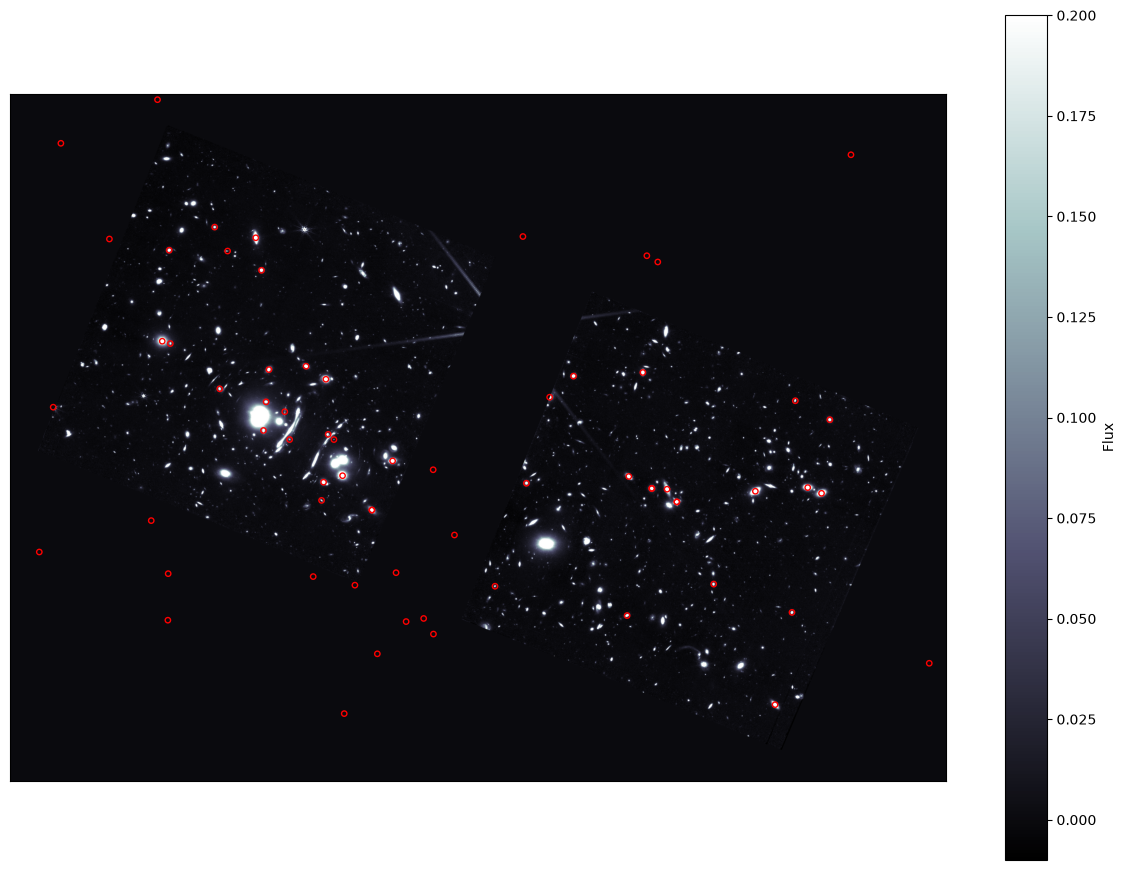

In [52]:
fig = plt.figure(figsize=(12, 8.8))
ax = fig.add_subplot(111, projection=wcs)

im = ax.imshow(data, origin='lower', cmap='bone', vmin=-0.01, vmax=0.2)

ax.set_xlabel('RA (J2000)')
ax.set_ylabel('Dec (J2000)')
ax.coords[0].set_major_formatter('d.dd')
ax.coords[1].set_major_formatter('d.dd')
# ax.coords.grid(True, color='white', ls='dotted', alpha=0.5)

ax.coords[0].set_format_unit(u.deg)
ax.coords[1].set_format_unit(u.deg)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

ax.scatter(
    ra_list, dec_list,
    transform=ax.get_transform('world'),
    s=15,                # marker size
    facecolor='none',    # open circles show underlying image better
    edgecolor='red',
    linewidth=1.0,
    marker='o',
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)

plt.colorbar(im, ax=ax, label='Flux')
plt.tight_layout()

plt.savefig("figures/mmt_spec_obj_map.png")